# 01 - Geospatial Overview

Defines the geographic scope of the analysis by selecting LGAs within the Niger-Benue flood risk zone and mapping key contextual layers including HFR communities, Floodscan inundation history, and NIHSA hydrological areas. We select all LGAs within 3km of the Niger or Benue Rivers.

**Outputs saved to Azure:**
- `ds-aa-nga-flooding/processed/selected_lgas.parquet` — Selected LGAs with hydrological area assignments
- `ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet` — Floodscan flood fraction time series for HFR LGAs

In [8]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import tempfile

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from exactextract import exact_extract
import ocha_stratus as stratus

from src.datasources import worldpop
from src.datasources import nihsa

load_dotenv()

## Load data

In [10]:
gdf_codab = stratus.codab.load_codab_from_blob("NGA", admin_level=0)
gdf_hydrological_areas = nihsa.load_hydological_areas()
gdf_hfr = nihsa.load_communities()
gdf_inundation = stratus.load_geoparquet_from_blob("ds-aa-nga-flooding/processed/google_inundation_history/combined_nga.parquet")
gdf_rivers = stratus.load_geoparquet_from_blob("ds-aa-nga-flooding/processed/selected_river_network.parquet")
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)

## Filtering LGAs

In [11]:
# Use EPSG:26392 (Minna / Nigeria Mid Belt) - designed for Nigeria
crs_nigeria = 26392

# Reproject to Nigeria-specific CRS
gdf_rivers_proj = gdf_rivers.to_crs(epsg=crs_nigeria)
gdf_lgas_proj = gdf_lga.to_crs(epsg=crs_nigeria)

# Create 3km buffer around rivers
rivers_buffer = gdf_rivers_proj.buffer(3000)  # 3000 meters

# Find LGAs within 3km of the Niger or Benue (no HFR community requirement)
gdf_lga_sel_proj = gdf_lgas_proj[gdf_lgas_proj.intersects(rivers_buffer.union_all())]

# Reproject back to 4326
gdf_lga_sel = gdf_lga_sel_proj.to_crs(epsg=4326)

print(f"Selected {len(gdf_lga_sel)} LGAs out of {len(gdf_lga)} total")

Selected 97 LGAs out of 774 total


## Assign each LGA to a hydrological area

In [12]:
# Ensure both GeoDataFrames have the same CRS
# If gdf_hydrological_areas has no CRS, set it
if gdf_hydrological_areas.crs is None:
    gdf_hydrological_areas = gdf_hydrological_areas.set_crs(epsg=4326)

# Reproject to Nigeria Mid Belt projection for accurate area calculations
crs_nigeria = 26392

gdf_lga_sel_proj = gdf_lga_sel.to_crs(epsg=crs_nigeria)
gdf_ha_proj = gdf_hydrological_areas.to_crs(epsg=crs_nigeria)

# Perform overlay in projected CRS
overlay = gpd.overlay(
    gdf_lga_sel_proj[['ADM2_PCODE', 'ADM2_EN', 'geometry']], 
    gdf_ha_proj[['HA', 'geometry']],  # adjust column name as needed
    how='intersection'
)

# Calculate area of each intersection (now in square meters)
overlay['intersection_area'] = overlay.geometry.area

# Find the HA with max intersection for each LGA
idx_max = overlay.groupby('ADM2_PCODE')['intersection_area'].idxmax()
lga_ha_mapping = overlay.loc[idx_max, ['ADM2_PCODE', 'HA']].set_index('ADM2_PCODE')

# Assign to gdf_lga_sel (back in original CRS)
gdf_lga_sel['HA_assigned'] = gdf_lga_sel['ADM2_PCODE'].map(lga_ha_mapping['HA'])

stratus.upload_parquet_to_blob(gdf_lga_sel, "ds-aa-nga-flooding/processed/selected_lgas.parquet")

## Define color mapping for Hydrological Areas

In [13]:
# Define color mapping for each Hydrological Area
# Using distinct colors for visual clarity
ha_colors = {
    '1': '#E63946',  # Red
    '2': '#F77F00',  # Orange
    '3': '#FCBF49',  # Yellow
    '4': '#06A77D',  # Green
    '5': '#0077B6',  # Blue
    '6': '#7209B7',  # Purple
}

# Get the actual HAs present in the data and create color mapping
unique_has = sorted(gdf_lga_sel['HA_assigned'].dropna().unique())
print(f"Hydrological Areas in selected LGAs: {unique_has}")

# Create a color list for the unique HAs
ha_color_list = [ha_colors.get(ha, '#999999') for ha in unique_has]

Hydrological Areas in selected LGAs: ['1', '2', '3', '4', '5']


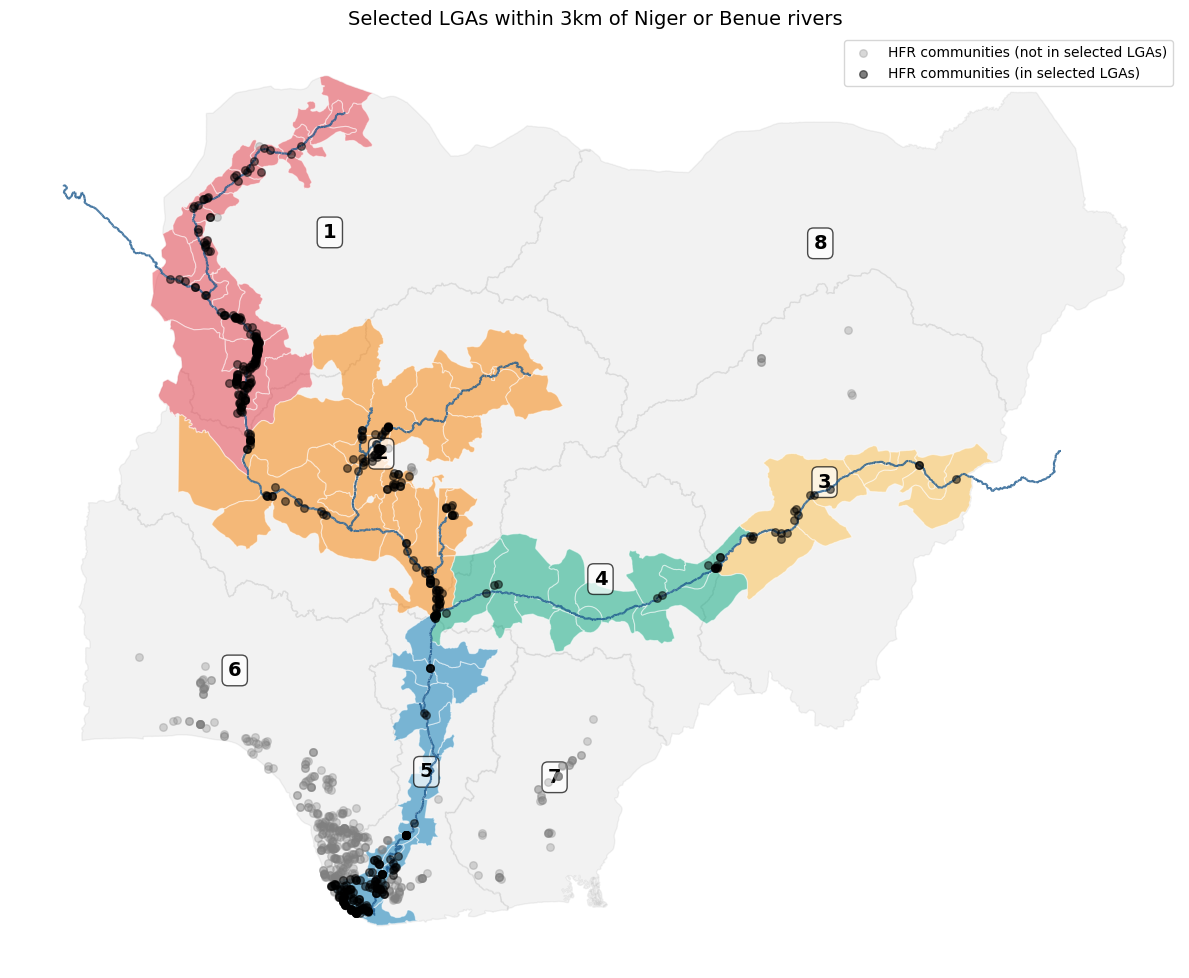

In [14]:
gdf_hfr_joined = gpd.sjoin(
    gdf_hfr,
    gdf_lga_sel[['geometry']],
    how='left',
    predicate='within',
)

# Create a column to indicate if in selected LGA
gdf_hfr_joined['in_selected_lga'] = gdf_hfr_joined.index_right.notna()

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Plot HAs as base layer with colors and labels
for idx, ha_row in gdf_hydrological_areas.iterrows():
    ha_name = ha_row['HA']
    color = ha_colors.get(ha_name, 'lightgray')
    
    # Plot the HA
    gpd.GeoDataFrame([ha_row], crs=gdf_hydrological_areas.crs).plot(
        ax=ax,
        facecolor='gray',
        edgecolor='gray',
        linewidth=1,
        alpha=0.1
    )
    
    # Add label at centroid
    centroid = ha_row.geometry.centroid
    ax.text(centroid.x, centroid.y, ha_name, 
            fontsize=14, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Plot selected LGAs colored by HA (handle NaN values with default color)
gdf_lga_sel['color'] = gdf_lga_sel['HA_assigned'].map(ha_colors).fillna('#CCCCCC')
gdf_lga_sel.plot(
    ax=ax,
    color=gdf_lga_sel['color'],
    edgecolor='white',
    linewidth=0.8,
    alpha=0.5
)

# Plot rivers
gdf_rivers.plot(
    ax=ax,
    color='#1E5A8E',  # OCHA river blue
    linewidth=1.5,
    alpha=0.8,
    zorder=4
)

# Plot HFR communities NOT in selected LGAs
gdf_hfr_joined[~gdf_hfr_joined['in_selected_lga']].plot(
    ax=ax,
    color='gray',
    markersize=30,
    alpha=0.3,
    label='HFR communities (not in selected LGAs)',
    zorder=5
)

# Plot HFR communities IN selected LGAs
gdf_hfr_joined[gdf_hfr_joined['in_selected_lga']].plot(
    ax=ax,
    color='black',
    markersize=30,
    alpha=0.5,
    label='HFR communities (in selected LGAs)',
    zorder=6
)

ax.set_title('Selected LGAs within 3km of Niger or Benue rivers', fontsize=14)
ax.legend(loc='upper right')
ax.set_axis_off()

plt.tight_layout()
# plt.show()
plt.savefig("figures/lga_ha_map.png", dpi=300)

## HFR Communities and Inundation Risk Areas

HFR communities (500m buffer) overlapping low-risk inundation areas: 724
HFR communities (500m buffer) NOT overlapping low-risk inundation areas: 161
Percentage overlapping: 81.8%


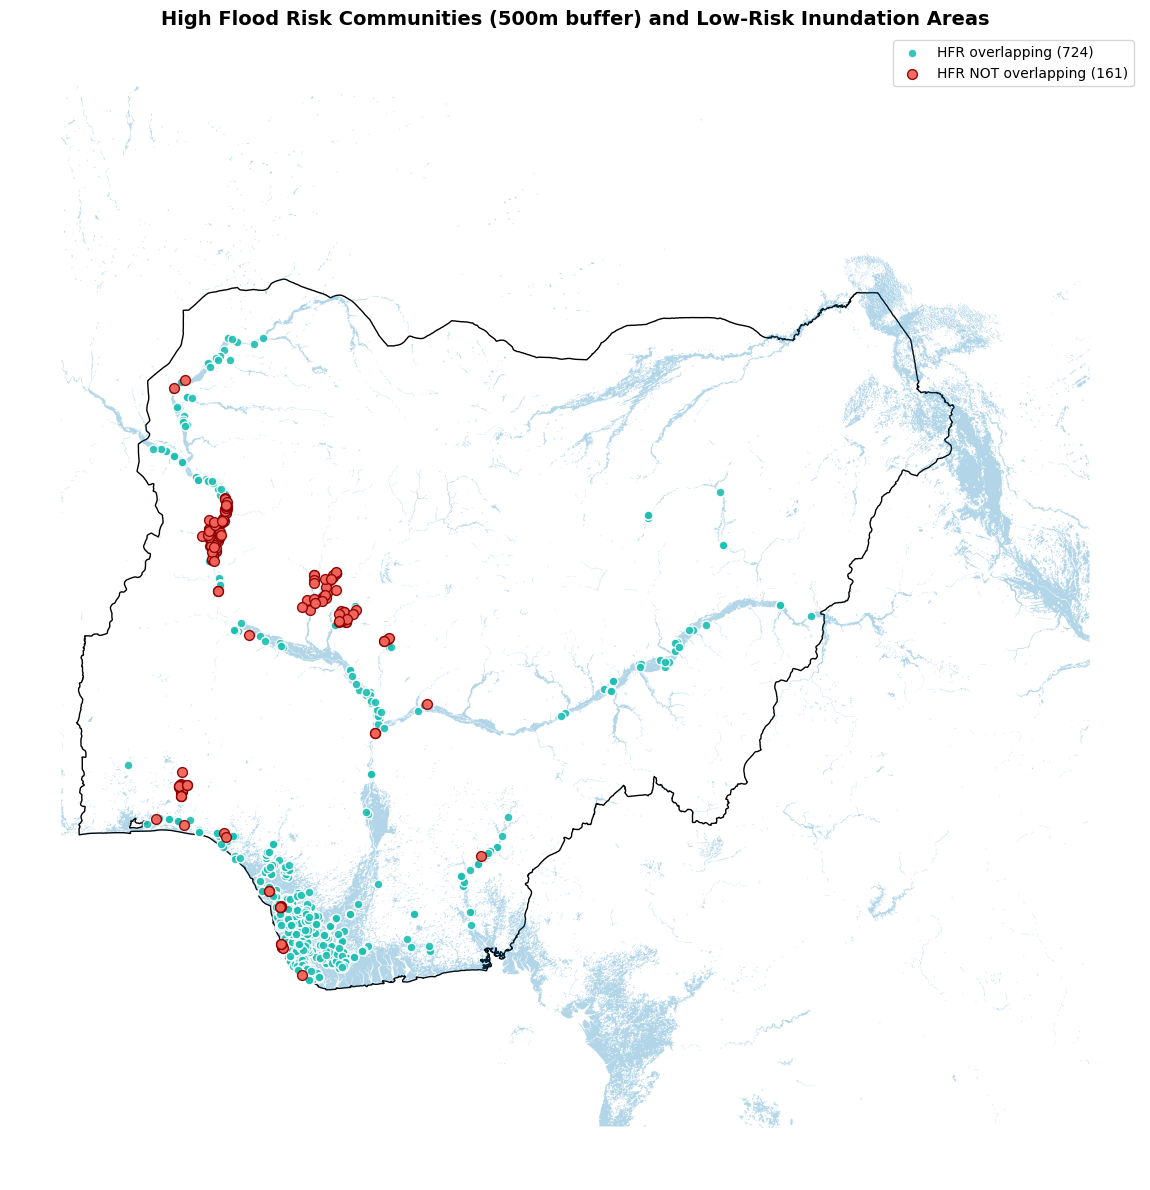

In [15]:
# Filter inundation data to low_risk layer
gdf_inundation_low_risk = gdf_inundation[gdf_inundation['risk'] == 'Low_risk'].copy()

# Ensure CRS is set for inundation data
if gdf_inundation_low_risk.crs is None:
    gdf_inundation_low_risk = gdf_inundation_low_risk.set_crs(epsg=4326)

# Ensure CRS is set for HFR data
if gdf_hfr.crs is None:
    gdf_hfr = gdf_hfr.set_crs(epsg=4326)

# Reproject to Nigeria Mid Belt projection for accurate buffering
gdf_hfr_proj = gdf_hfr.to_crs(epsg=26392)
gdf_inundation_proj = gdf_inundation_low_risk.to_crs(epsg=26392)

# Create 500m buffer around each HFR community
gdf_hfr_buffered = gdf_hfr_proj.copy()
gdf_hfr_buffered['geometry'] = gdf_hfr_proj.buffer(500)  # 500 meters

# Spatial join to determine which HFR buffers intersect with inundation areas
gdf_hfr_inundation = gpd.sjoin(
    gdf_hfr_buffered,
    gdf_inundation_proj[['geometry']],
    how='left',
    predicate='intersects'
)

# Create a column to indicate if buffer overlaps inundation area
gdf_hfr_inundation['overlaps_inundation'] = gdf_hfr_inundation.index_right.notna()

# Reproject back to 4326 for plotting
gdf_hfr_inundation = gdf_hfr_inundation.to_crs(epsg=4326)

# Also merge overlap status back to original HFR points for coloring
gdf_hfr_with_status = gdf_hfr.copy()
gdf_hfr_with_status['overlaps_inundation'] = gdf_hfr_inundation['overlaps_inundation'].values

# Count communities with overlapping buffers
n_overlaps = gdf_hfr_inundation['overlaps_inundation'].sum()
n_no_overlap = (~gdf_hfr_inundation['overlaps_inundation']).sum()

print(f"HFR communities (500m buffer) overlapping low-risk inundation areas: {n_overlaps}")
print(f"HFR communities (500m buffer) NOT overlapping low-risk inundation areas: {n_no_overlap}")
print(f"Percentage overlapping: {n_overlaps / len(gdf_hfr_inundation) * 100:.1f}%")

# Create the plot
fig, ax = plt.subplots(figsize=(14, 12))

# Plot country boundary
gdf_codab.plot(
    ax=ax,
    facecolor='none',
    edgecolor='black',
    linewidth=1
)

# Plot inundation areas
gdf_inundation_low_risk.plot(
    ax=ax,
    facecolor='#0077B6',
    edgecolor='none',
    alpha=0.3,
)

# Plot HFR community points - overlapping ones
gdf_hfr_with_status[gdf_hfr_with_status['overlaps_inundation']].plot(
    ax=ax,
    color='#1EBFB3',  # OCHA teal
    markersize=40,
    alpha=0.9,
    edgecolor='white',
    linewidth=1,
    label=f'HFR overlapping ({n_overlaps})',
    zorder=7
)

# Plot HFR community points - NOT overlapping ones (highlighted)
gdf_hfr_with_status[~gdf_hfr_with_status['overlaps_inundation']].plot(
    ax=ax,
    color='#F2645A',  # OCHA coral
    markersize=50,
    alpha=0.95,
    edgecolor='darkred',
    linewidth=1,
    label=f'HFR NOT overlapping ({n_no_overlap})',
    zorder=8
)

ax.set_title('High Flood Risk Communities (500m buffer) and Low-Risk Inundation Areas', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_axis_off()

plt.tight_layout()
plt.show()
# plt.savefig("figures/hfr_inundation_overlap.png", dpi=300)

## Retrieve Floodscan data for selected LGAs

In [ ]:
# engine = stratus.get_engine("prod")
# pcodes = list(gdf_lga_sel['ADM2_PCODE'])

# with engine.connect() as conn:
#     query = """
#         SELECT * 
#         FROM floodscan 
#         WHERE pcode IN %(pcodes)s
#         AND band = 'SFED'
#     """
#     df_floodscan = pd.read_sql(query, engine, params={'pcodes': tuple(pcodes)}, parse_dates=["valid_date"])

# # Save floodscan data for faster acccess
# stratus.upload_parquet_to_blob(df_floodscan, "ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet")

In [17]:
df_floodscan = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet")

## Time series plots with normalized dates

In [ ]:
# # Merge HA assignment
# df_floodscan = df_floodscan.merge(
#     gdf_lga_sel[['ADM2_PCODE', 'ADM2_EN', 'HA_assigned']],
#     left_on='pcode',
#     right_on='ADM2_PCODE',
#     how='left'
# )

# # Extract year and create normalized date for x-axis (month-day only)
# df_floodscan['year'] = df_floodscan['valid_date'].dt.year
# df_floodscan['normalized_date'] = df_floodscan['valid_date'].apply(
#     lambda x: x.replace(year=2024)
# )

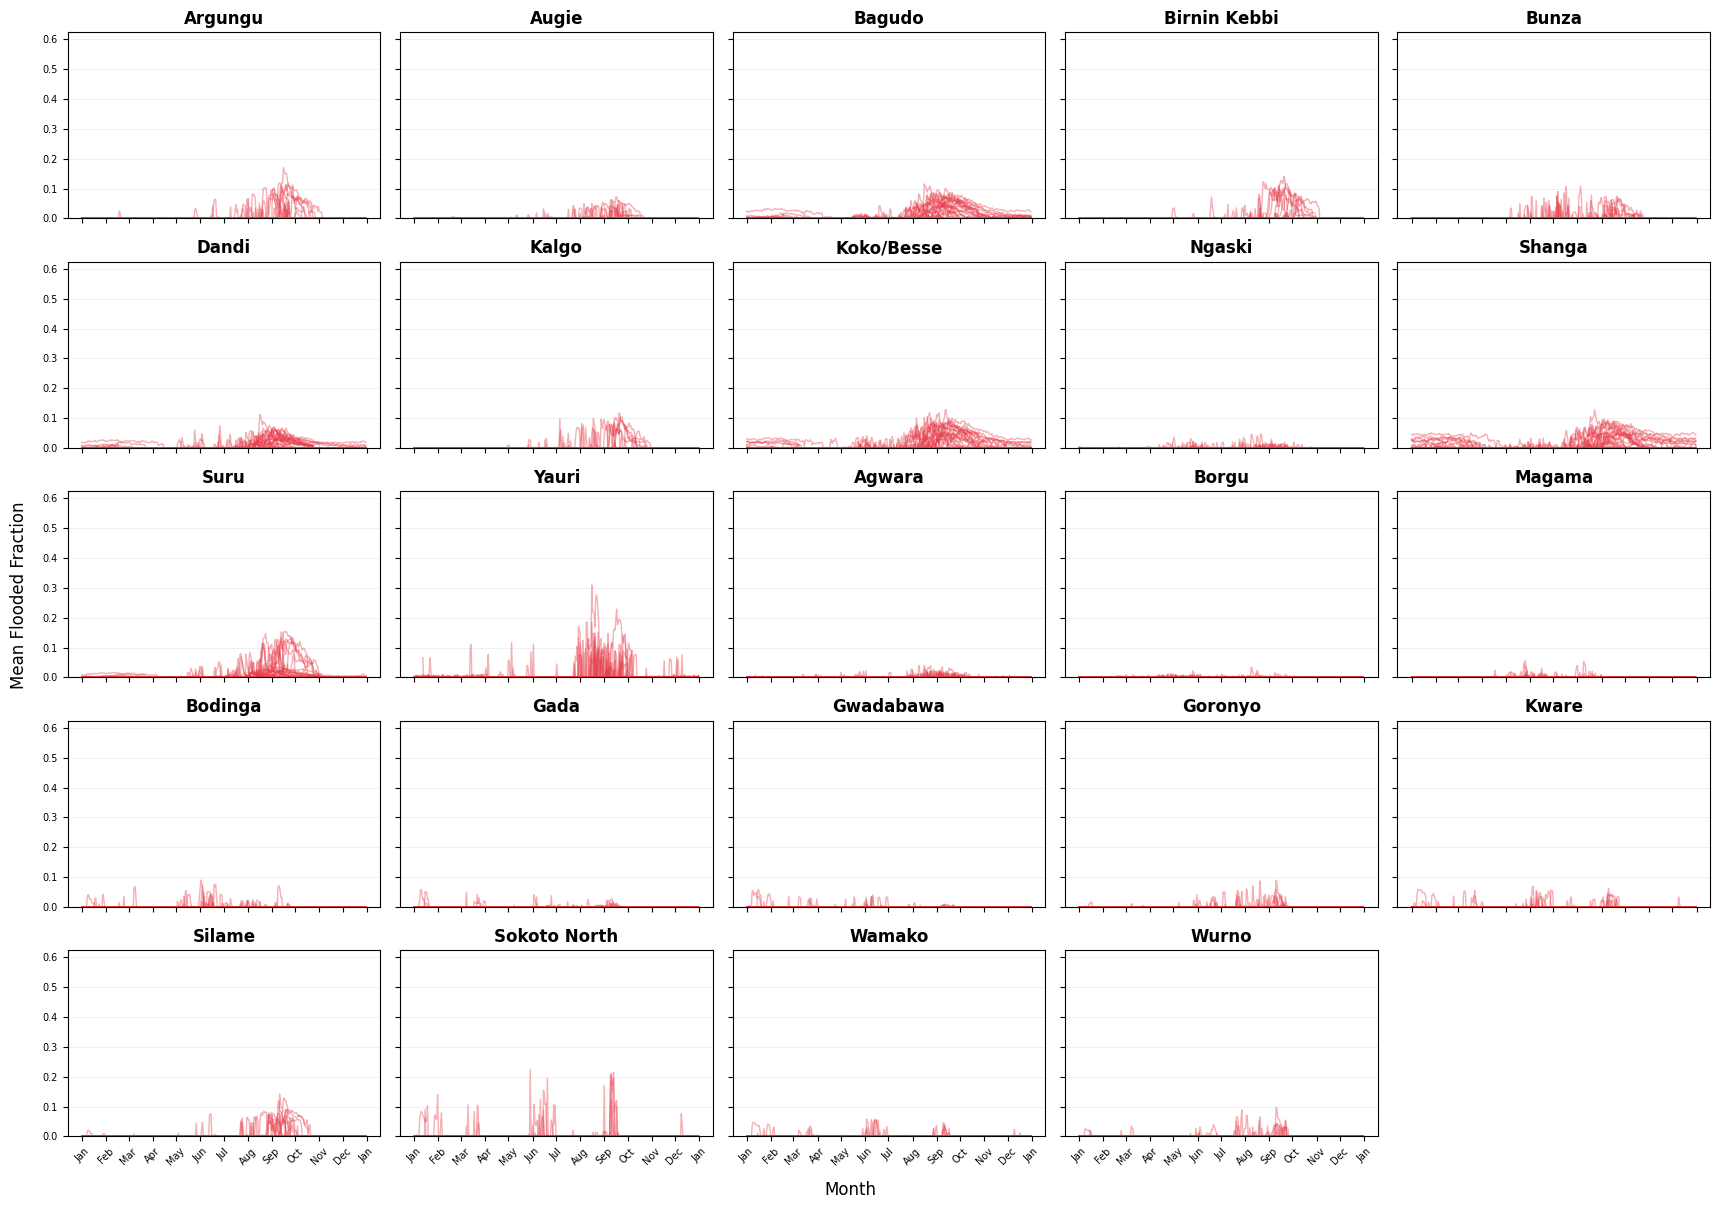

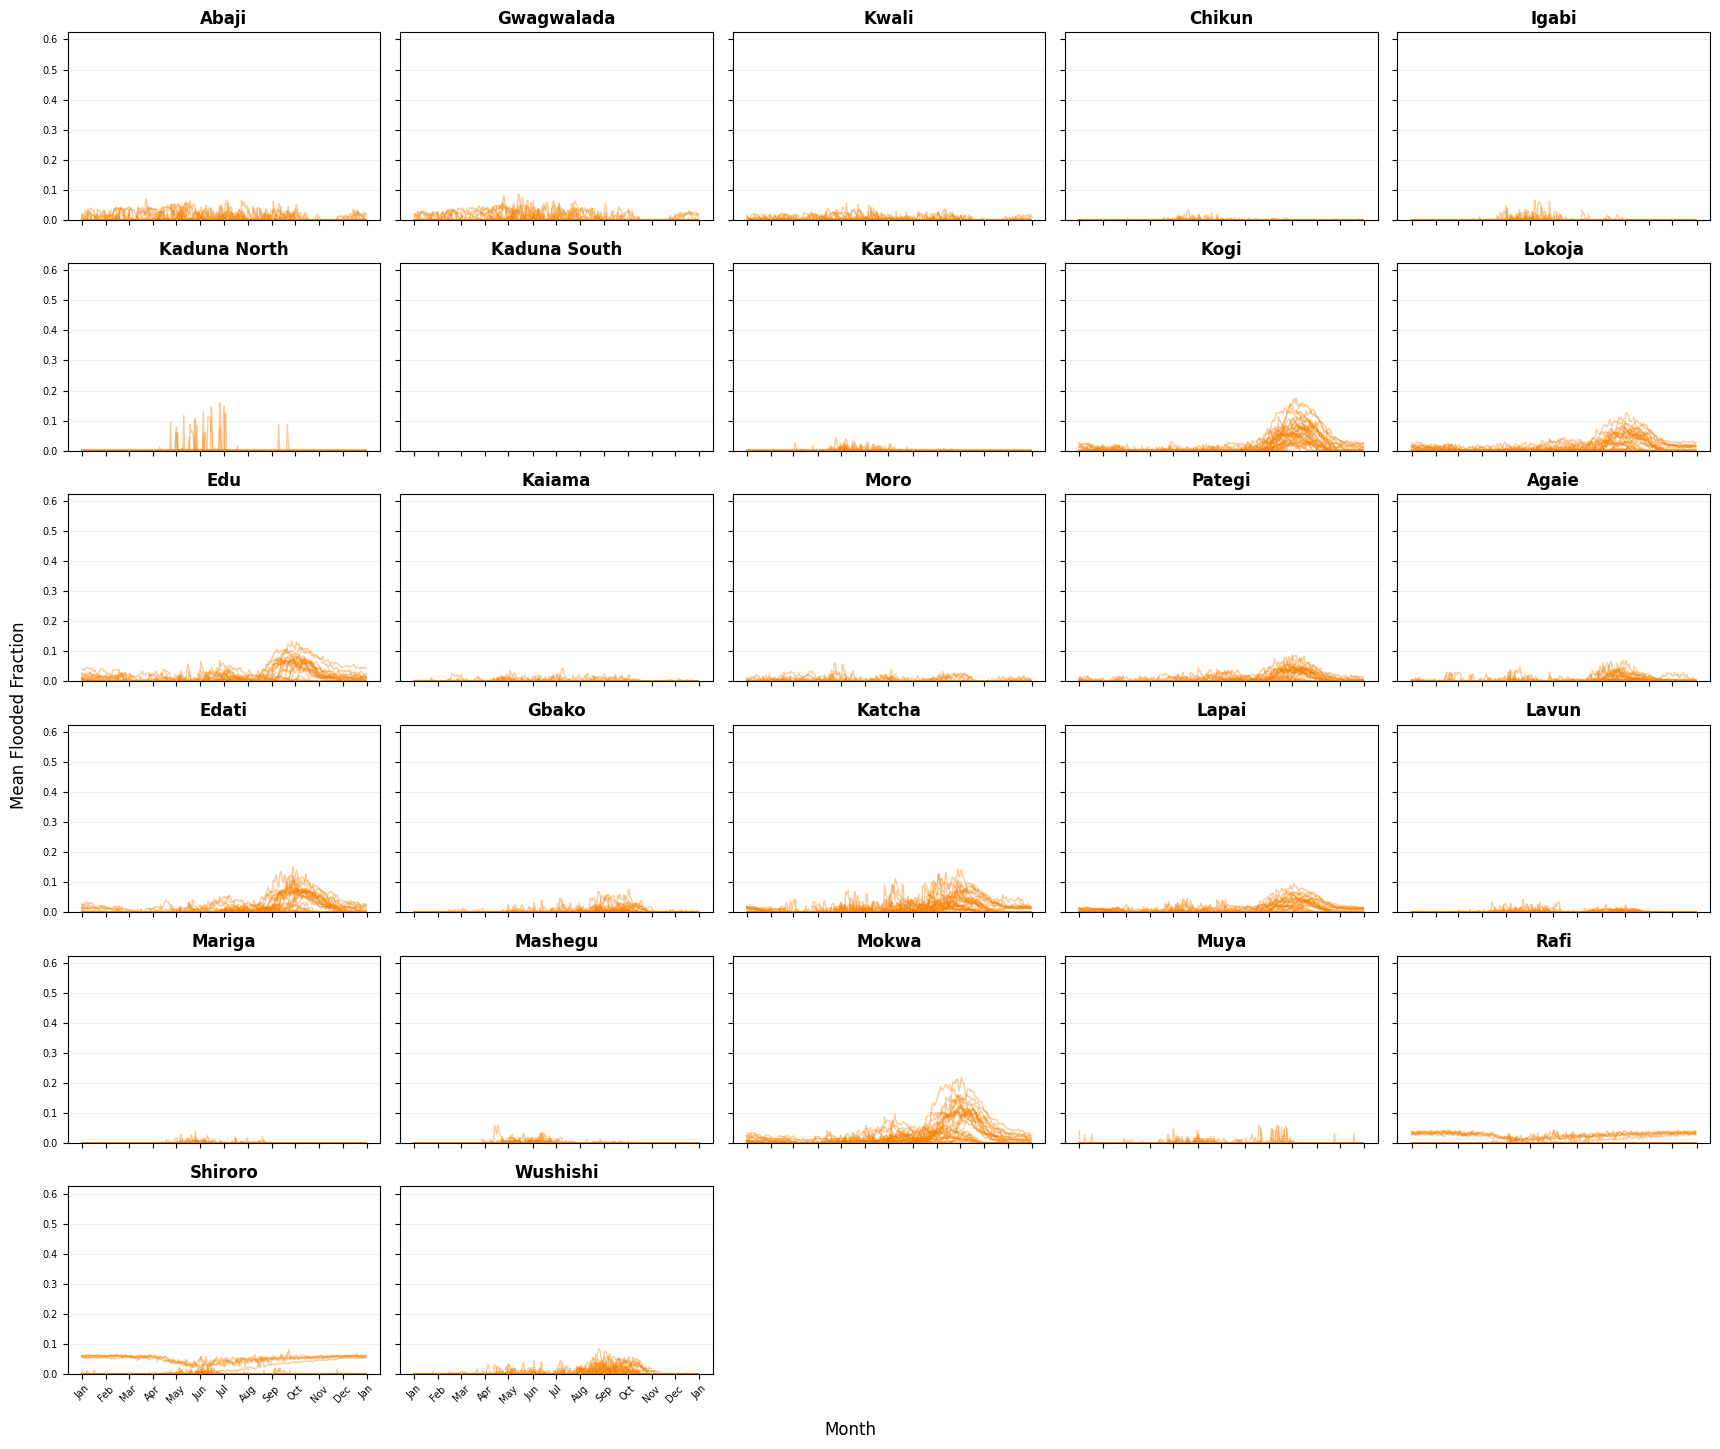

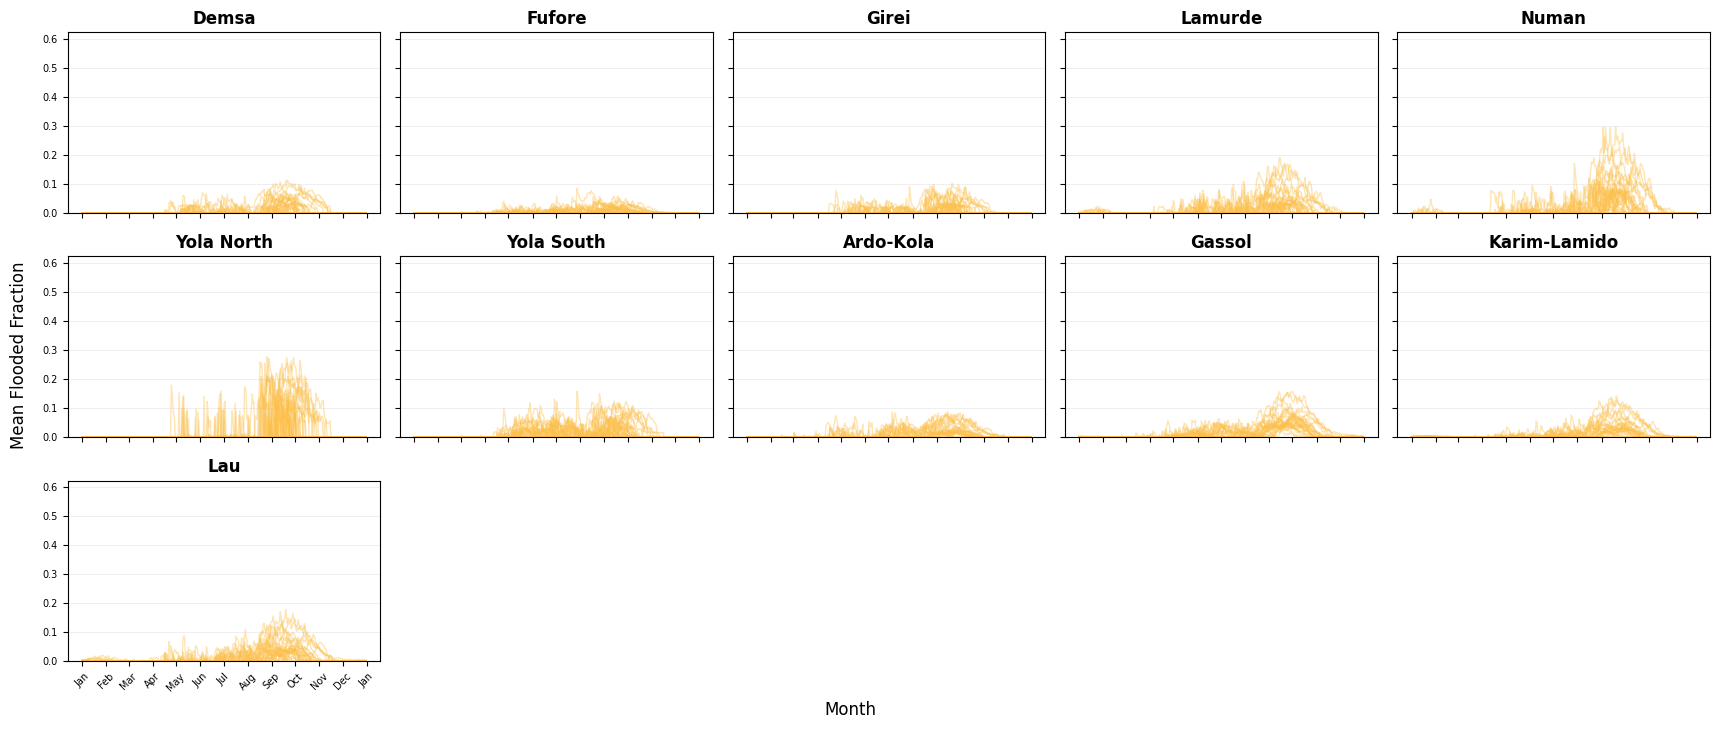

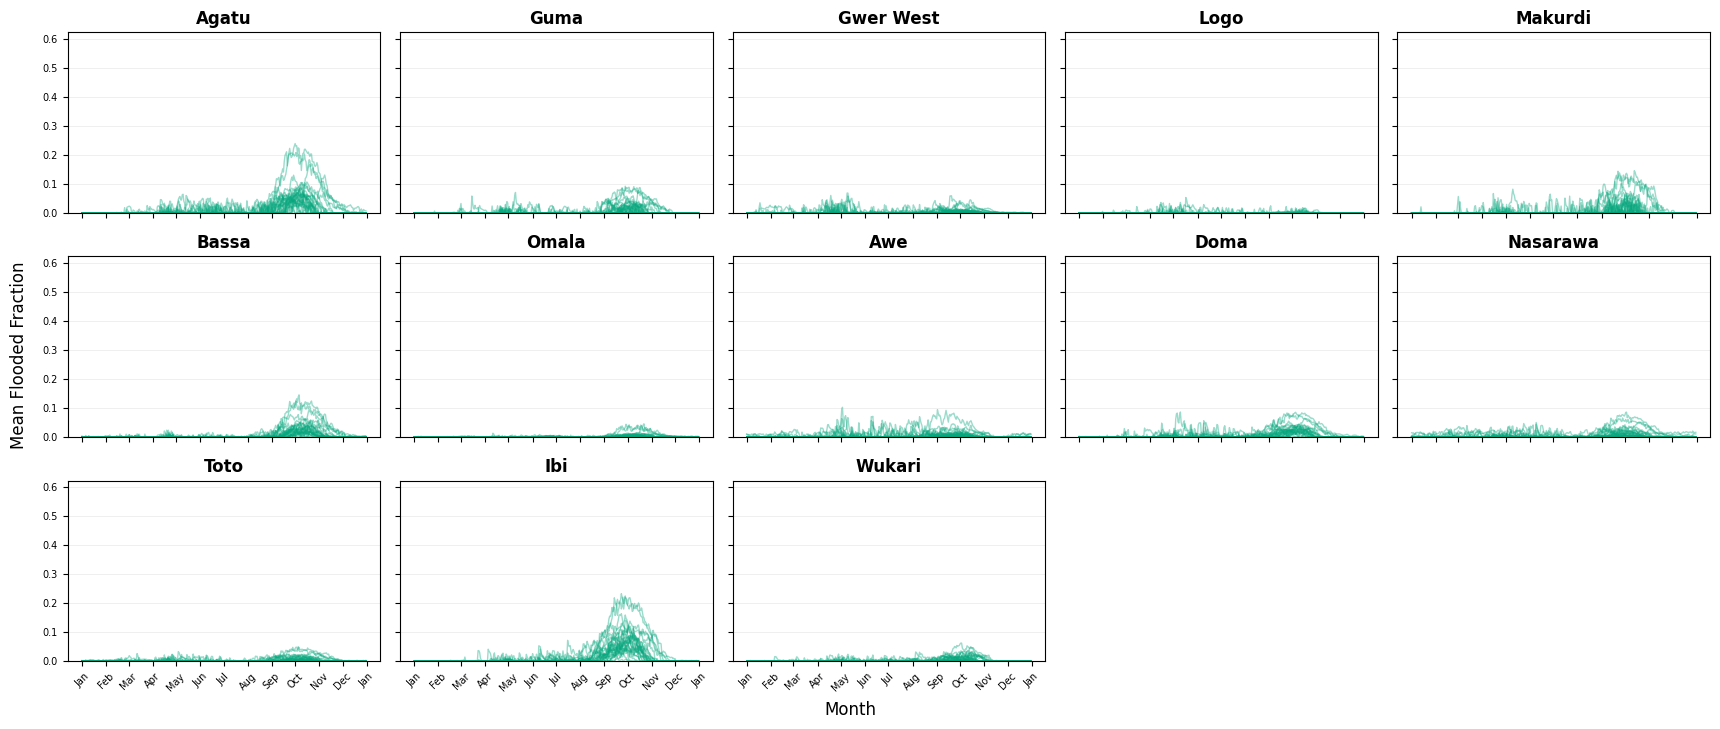

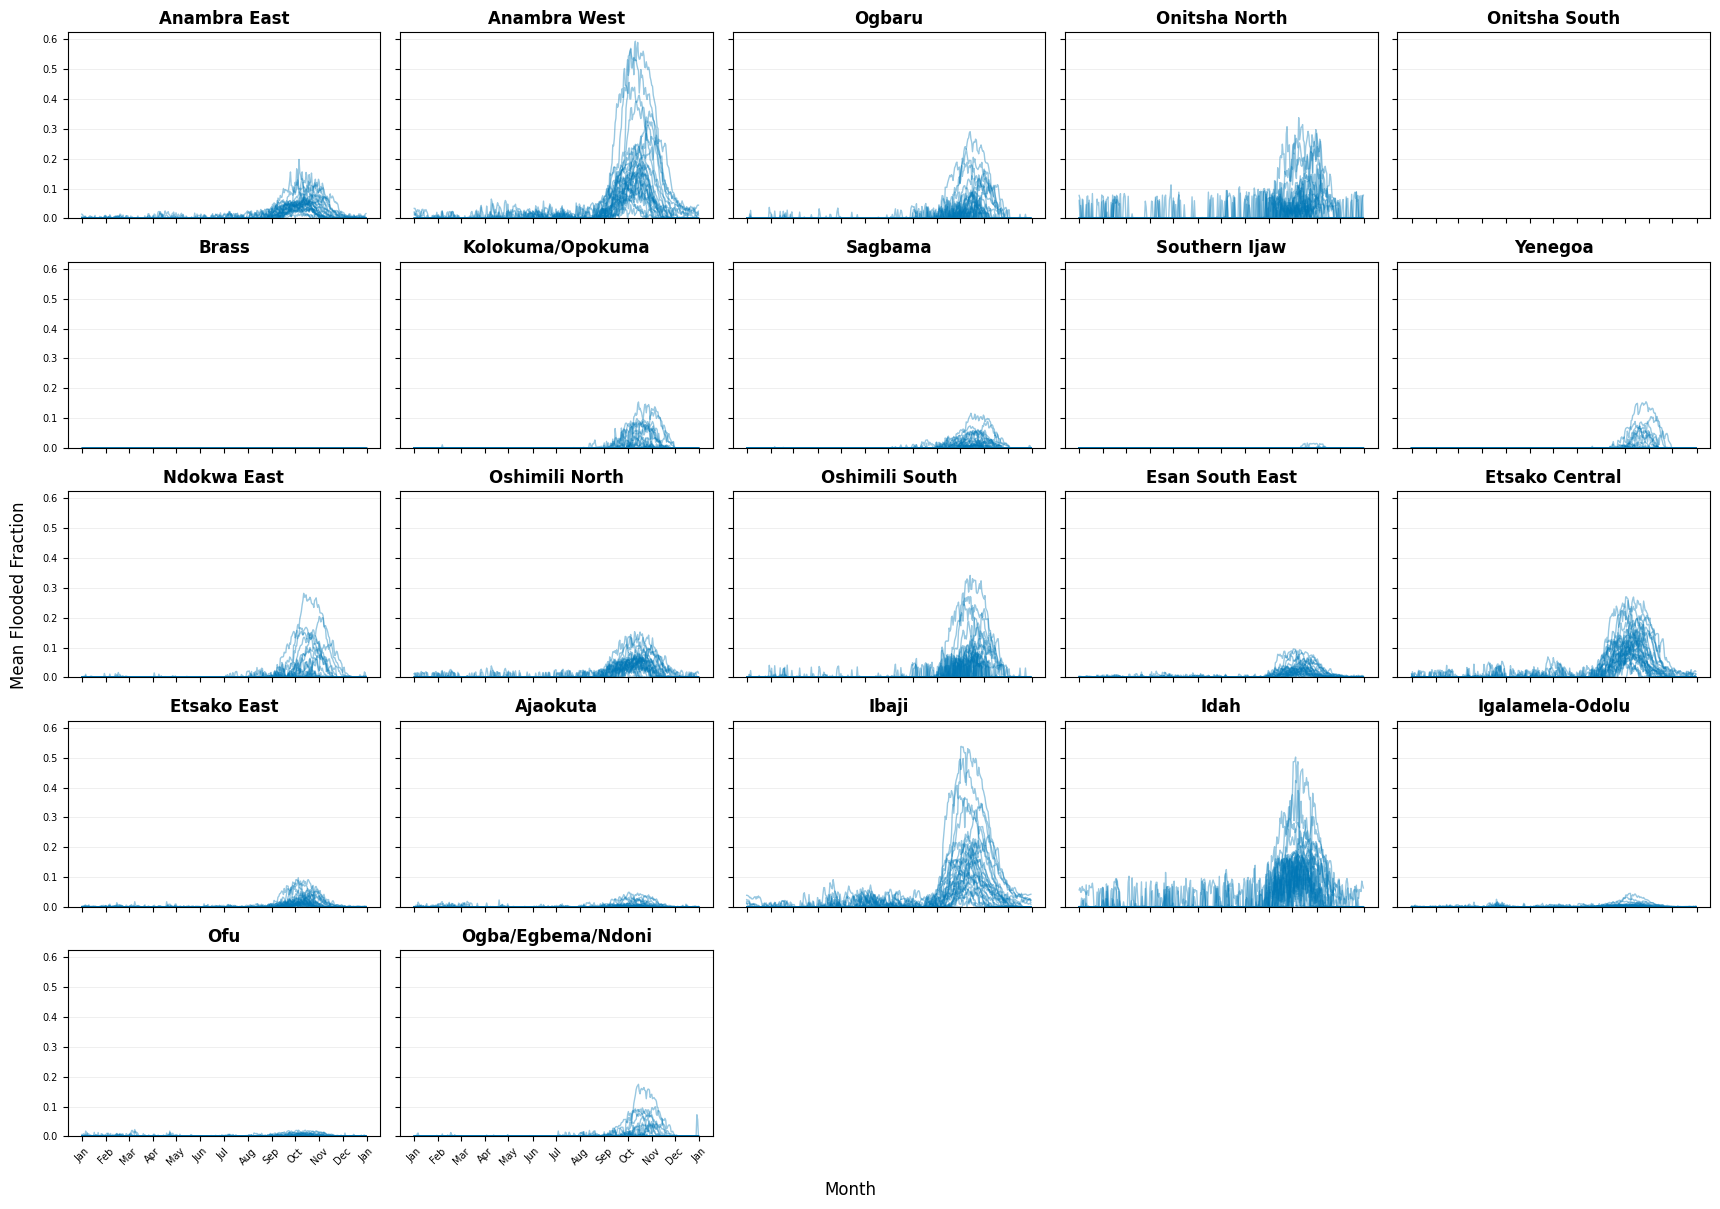

In [22]:
# Get unique years
years = sorted(df_floodscan['year'].unique())

# Get unique HAs
unique_has = sorted(df_floodscan['HA_assigned'].dropna().unique())

# Determine global y-axis range across all data
y_max = df_floodscan['mean'].max()

# Create separate figure for each HA
for ha in unique_has:
    # Filter data for this HA
    df_ha = df_floodscan[df_floodscan['HA_assigned'] == ha]
    pcodes = sorted(df_ha['pcode'].unique())
    n_pcodes = len(pcodes)
    
    # Get HA color
    ha_color = ha_colors.get(ha, '#007CE0')
    
    # Calculate grid dimensions (max 5 columns)
    n_cols = min(5, n_pcodes)
    n_rows = int(np.ceil(n_pcodes / n_cols))
    
    # Create subplots for this HA
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 2.5), 
                              sharex=True, sharey=True)
    if n_pcodes == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_pcodes > n_cols else axes
    
    # Plot each pcode in its own subplot
    for idx, pcode in enumerate(pcodes):
        ax = axes[idx]
        df_pcode = df_ha[df_ha['pcode'] == pcode]

        # Get LGA name
        lga_info = gdf_lga_sel[gdf_lga_sel['ADM2_PCODE'] == pcode]
        lga_name = lga_info['ADM2_EN'].values[0] if len(lga_info) > 0 else pcode

        # Plot each year as a separate line with HA color
        for year in years:
            df_year = df_pcode[df_pcode['year'] == year].sort_values('normalized_date')
            if len(df_year) > 0:
                ax.plot(df_year['normalized_date'], df_year['mean'],
                        color=ha_color, alpha=0.4, linewidth=1)

        ax.set_title(lga_name, fontsize=12, fontweight='bold')
        
        # Standardize y-axis range
        ax.set_ylim(0, y_max * 1.05)
        
        # Add horizontal grid lines only
        ax.grid(True, axis='y', color='lightgrey', alpha=0.5, linewidth=0.5)
        
        # Format x-axis to show month abbreviations
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)

    # Hide unused subplots
    for idx in range(n_pcodes, len(axes)):
        axes[idx].set_visible(False)

    # Add common labels
    fig.text(0.5, 0.02, 'Month', ha='center', fontsize=12)
    fig.text(0.02, 0.5, 'Mean Flooded Fraction', va='center', rotation='vertical', fontsize=12)

    plt.tight_layout(rect=[0.03, 0.03, 1, 0.98])
    plt.show()
    # plt.savefig(f"figures/lga_flooded_fraction_{ha}.png", dpi=300)

## Population exposed to flooding per LGA

Estimates the number of people in each selected LGA living within the Google inundation history low-risk zone, using WorldPop gridded population data (2020, 1 km).

In [40]:
# Load WorldPop 2025 100m gridded population for Nigeria
da_pop = worldpop.load_worldpop_from_stac("NGA", year=2025, resolution="100m")
da_pop = da_pop.rio.write_crs("EPSG:4326")
da_pop = da_pop.where(da_pop > 0)  # mask nodata / negative fill values

In [41]:
# Clip WorldPop to the selected LGAs, reproject to ensure a clean geotransform,
# then upload as a COG for the web map
da_pop_lga = (
    da_pop
    .rio.clip(gdf_lga_sel.geometry, all_touched=True)
    # .rio.reproject("EPSG:4326")
)
blob_name = "worldpop/nga_lga_sel_2025_100m.tif"
stratus.upload_cog_to_blob(da_pop_lga, blob_name, container_name="web")

In [52]:
# Intersect LGAs with inundation polygons so we only sum population within flooded areas
gdf_lga_inundation = gpd.overlay(
    gdf_lga_sel[["ADM2_PCODE", "ADM2_EN", "HA_assigned", "geometry"]],
    gdf_inundation_low_risk[["geometry"]],
    how="intersection",
)

# Sum population within each intersection polygon, then aggregate by LGA
df_extract = exact_extract(da_pop, gdf_lga_inundation, ["sum"], output="pandas")
gdf_lga_inundation["pop_exposed"] = df_extract["sum"].fillna(0)

df_pop_exposed = (
    gdf_lga_inundation.groupby(["ADM2_PCODE", "ADM2_EN", "HA_assigned"])["pop_exposed"]
    .sum()
    .round()
    .astype(int)
    .reset_index()
    .sort_values("pop_exposed", ascending=False)
    .reset_index(drop=True)
)
print(f"Total population exposed across all LGAs: {df_pop_exposed['pop_exposed'].sum():,.0f}")
df_pop_exposed

Total population exposed across all LGAs: 3,827,646


,ADM2_PCODE,ADM2_EN,HA_assigned,pop_exposed
0,NG006008,Yenegoa,5,1236319
1,NG033016,Ogba/Egbema/Ndoni,5,305348
2,NG010015,Oshimili South,5,194783
3,NG006007,Southern Ijaw,5,165796
4,NG006006,Sagbama,5,146444
...,...,...,...,...
92,NG007012,Logo,4,860
93,NG023008,Igalamela-Odolu,5,843
94,NG019014,Kauru,2,535
95,NG007008,Gwer West,4,336


In [65]:
# Save population exposure per LGA to blob storage for the web map
stratus.upload_parquet_to_blob(
    df_pop_exposed,
    "ds-aa-nga-flooding/processed/lga_pop_exposed.parquet",
)

/var/folders/rv/xmclt0vn5y7cqt46s5xq3h080000gn/T/ipykernel_99528/1614307362.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "Reds_truncated", mcm.get_cmap("Reds")(np.linspace(0.2, 1.0, 256))


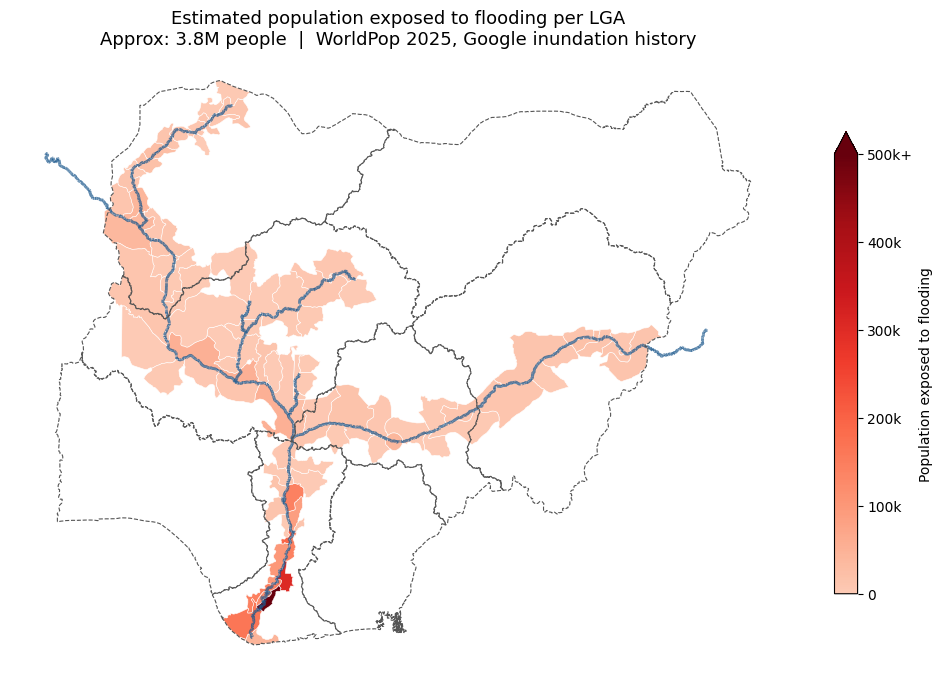

In [ ]:
# Choropleth: total exposed population per LGA
gdf_pop_map = gdf_lga_sel.merge(df_pop_exposed[["ADM2_PCODE", "pop_exposed"]], on="ADM2_PCODE", how="left")
# Replace zeros with NaN so they render as grey via missing_kwds
gdf_pop_map["pop_exposed_plot"] = gdf_pop_map["pop_exposed"].replace(0, float("nan"))

total_exposed = gdf_pop_map["pop_exposed"].fillna(0).sum()

fig, ax = plt.subplots(figsize=(10, 8))

# Truncate the Reds colormap so it starts at a darker shade (skip the near-white end)
cmap_reds = mcolors.LinearSegmentedColormap.from_list(
    "Reds_truncated", mcm.get_cmap("Reds")(np.linspace(0.2, 1.0, 256))
)
norm = mcolors.Normalize(vmin=0, vmax=500_000)
gdf_pop_map.plot(
    column="pop_exposed_plot",
    ax=ax,
    cmap=cmap_reds,
    norm=norm,
    legend=True,
    legend_kwds={
        "label": "Population exposed to flooding",
        "orientation": "vertical",
        "shrink": 0.6,
        "format": lambda x, _: "500k+" if x >= 500_000 else (f"{int(x/1000)}k" if x >= 1000 else str(int(x))),
        "extend": "max",
    },
    missing_kwds={"color": "#cccccc", "label": "No exposure"},
    edgecolor="white",
    linewidth=0.4,
)

gdf_rivers.plot(ax=ax, color="#1E5A8E", linewidth=2.0, alpha=0.7)
gdf_hydrological_areas.boundary.plot(ax=ax, color="#555555", linewidth=0.8, linestyle="--")

ax.set_title(
    f"Estimated population exposed to flooding per LGA\n"
    f"Approx: 3.8M people  |  WorldPop 2025, Google inundation history",
    fontsize=13,
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/lga_population_exposed_map.png", dpi=300)